In [1]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [2]:
heart_df = pd.read_csv("heart.csv")
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
heart_df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [6]:
heart_df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
heart_df.nunique()

Age                50
Sex                 2
ChestPainType       4
RestingBP          67
Cholesterol       222
FastingBS           2
RestingECG          3
MaxHR             119
ExerciseAngina      2
Oldpeak            53
ST_Slope            3
HeartDisease        2
dtype: int64

In [8]:
cat_col=heart_df.select_dtypes(include='object').columns

In [9]:
for col in cat_col:
    print(col)
    print((heart_df[col].unique()),list(range(heart_df[col].nunique())))
    heart_df[col].replace((heart_df[col].unique()), range(heart_df[col].nunique()), inplace =True)
    print('*'*90)
    print()

Sex
['M' 'F'] [0, 1]
******************************************************************************************

ChestPainType
['ATA' 'NAP' 'ASY' 'TA'] [0, 1, 2, 3]
******************************************************************************************

RestingECG
['Normal' 'ST' 'LVH'] [0, 1, 2]
******************************************************************************************

ExerciseAngina
['N' 'Y'] [0, 1]
******************************************************************************************

ST_Slope
['Up' 'Flat' 'Down'] [0, 1, 2]
******************************************************************************************



In [10]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,1,1
914,68,0,2,144,193,1,0,141,0,3.4,1,1
915,57,0,2,130,131,0,0,115,1,1.2,1,1
916,57,1,0,130,236,0,2,174,0,0.0,1,1


In [12]:
heart_df['Cholesterol'].replace(0,np.nan, inplace=True)

In [13]:
np.nan

nan

In [15]:
from sklearn.impute import KNNImputer
imputer =KNNImputer(n_neighbors=3)
after_impute= imputer.fit_transform(heart_df)
heart_df=pd.DataFrame(after_impute, columns = heart_df.columns)

In [16]:
heart_df['Cholesterol'].isna().sum()

np.int64(0)

In [17]:
heart_df['RestingBP'][heart_df['RestingBP'] ==0]

449    0.0
Name: RestingBP, dtype: float64

In [18]:
heart_df['RestingBP'].replace(0,np.nan, inplace=True)
imputer =KNNImputer(n_neighbors=3)
after_impute= imputer.fit_transform(heart_df)
heart_df=pd.DataFrame(after_impute, columns = heart_df.columns)

In [19]:
heart_df['RestingBP'].unique()

array([140., 160., 130., 138., 150., 120., 110., 136., 115., 100., 124.,
       113., 125., 145., 112., 132., 118., 170., 142., 190., 135., 180.,
       108., 155., 128., 106.,  92., 200., 122.,  98., 105., 133.,  95.,
        80., 137., 185., 165., 126., 152., 116., 144., 154., 134., 104.,
       139., 131., 141., 178., 146., 158., 123., 102.,  96., 143., 172.,
       156., 114., 127., 101., 174.,  94., 148., 117., 192., 129., 164.])

In [21]:
withoutOldPeak= heart_df.columns
withoutOldPeak= withoutOldPeak.drop('Oldpeak')
heart_df[withoutOldPeak]=heart_df[withoutOldPeak].astype('int32')

In [22]:
!pip install plotly

In [23]:
import plotly.express as px

In [28]:
heart_df.corr()['HeartDisease'][:-1].sort_values()

MaxHR            -0.400421
Sex              -0.305445
RestingECG        0.061011
Cholesterol       0.101263
RestingBP         0.118333
FastingBS         0.267291
Age               0.282039
Oldpeak           0.403951
ChestPainType     0.459017
ExerciseAngina    0.494282
ST_Slope          0.558771
Name: HeartDisease, dtype: float64

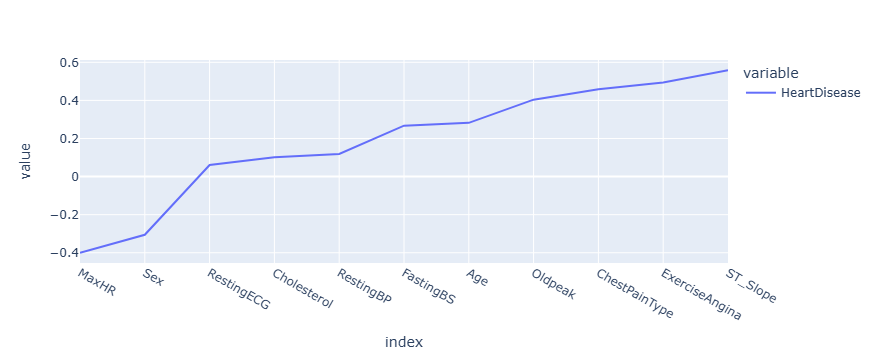

In [25]:
px.line(heart_df.corr()['HeartDisease'][:-1].sort_values())

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    heart_df.drop('HeartDisease', axis=1),
    heart_df['HeartDisease'],
    test_size=0.2,
    random_state=42,
    stratify=heart_df['HeartDisease']
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
best_solver = ''
test_score = np.zeros(6)
for i, n in enumerate(solver):
    lr = LogisticRegression(solver=n).fit(X_train, y_train)
    test_score[i] = lr.score(X_test, y_test)
    if lr.score(X_test, y_test) == test_score.max():
        best_solver = n

print(best_solver)
lr = LogisticRegression(solver=best_solver)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f'LogisticRegression Score: {accuracy_score(y_test, lr_pred)}')

newton-cholesky
LogisticRegression Score: 0.8586956521739131


In [35]:
#Decision Tree

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth':[3,4,5,6,7,8],
    'min_samples_split':[2,3,4],
    'min_samples_leaf':[1,2,3,4],
    'random_state':[0,42]
}

grid_search = GridSearchCV(dtree, param_grid, cv=5)
grid_search.fit(X_train, y_train)
Ctree = DecisionTreeClassifier(**grid_search.best_params_, class_weight='balanced')
Ctree.fit(X_train, y_train)
dtc_pred = Ctree.predict(X_test)
print("DecisionTrees's Accuracy: ", accuracy_score(y_test, dtc_pred))

DecisionTrees's Accuracy:  0.8097826086956522


In [45]:
import pickle 
file = open('LogisticRegression.pkl','wb')
pickle.dump(lr,file)

In [39]:
import pickle 
file = open('DecisionTree.pkl','wb')
pickle.dump(lr,file)

In [44]:
import pickle 
file = open('RandomForest.pkl','wb')
pickle.dump(lr,file)

In [42]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Random Forest model
rfc = RandomForestClassifier(random_state=42)

# Parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'max_features': ['sqrt']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    cv=3,
    n_jobs=1   # changed from -1 to 1
)

# Train model
grid_search.fit(X_train, y_train)

# Best model
rfctree = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42
)

rfctree.fit(X_train, y_train)

# Prediction
rfc_pred = rfctree.predict(X_test)

# Accuracy
print("Best Parameters:", grid_search.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, rfc_pred))

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}
Random Forest Accuracy: 0.8858695652173914


In [3]:
import pickle

modelnames = [
    'Decisiontree.pkl',
    'LogisticRegression.pkl',
    'RandomForest.pkl',
    'SVM.pkl'
]

for modelname in modelnames:
    try:
        model = pickle.load(open(modelname, 'rb'))  # rb not wb
        print(modelname, "Loaded Successfully")
    except Exception as e:
        print(modelname, "Error:", e)

Decisiontree.pkl Loaded Successfully
LogisticRegression.pkl Loaded Successfully
RandomForest.pkl Loaded Successfully
SVM.pkl Error: Ran out of input
